In [1]:
# State 2개 실습
!pip install langgraph

{'counter': 1, 'alphabet': ['오늘은 금요일']}
{'counter': 2, 'alphabet': ['보람찬 한 주']}


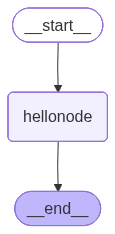

In [3]:
from langgraph import graph
from typing import TypedDict
from langgraph.graph import StateGraph, END, START

class State(TypedDict):
  counter:int
  alphabet:str

def node_a(state:State) -> State:
  state["counter"] += 1    # 실행 횟수 누적함

  if state["counter"] == 1:
    state["alphabet"] = ["오늘은 금요일"]
  elif state["counter"] == 2:
    state["alphabet"] = ["보람찬 한 주"]

  return state

def build_graph():
  graph_builder = StateGraph(State)

  graph_builder.add_node("hellonode", node_a)

  graph_builder.add_edge(START, "hellonode")     # START를 선언해줬기 때문에 진입점을 지정할 필요 없음
  graph_builder.add_edge("hellonode", END)

  return graph_builder.compile()

if __name__=="__main__":
  graph = build_graph()

  state:State = {"counter":0, "alphabet":[]}    # 실행 전 초기화


  # 1번째 실행
  state = graph.invoke(state)
  print(state)

  # 2번째 실행
  state = graph.invoke(state)
  print(state)

  # invoke 2번 좋은 방법 아니다(현업/실무에서 쓰지 않는다) -> "분기(conditional edge)"를 사용해서 작업하면 invoke 줄일 수 있다.

  # 시각화
  try:
    from IPython.display import Image, display
    graph_obj = graph.get_graph()
    png_bytes = graph_obj.draw_mermaid_png()     # Mermaid 기반 png 이미지 얻기
    display(Image(png_bytes))

  except Exception as e:
    print(f"그래프 시각화 실패 : {e}")